# Does Founder Authority Diffusion Predict OSS Survival?

This notebook demonstrates the analysis stages (Stages 5-8) of `method.py`, a re-implementation of Avelino et al.'s (ESEM 2019) Degree-of-Authorship (DOA) / Truck-Factor (TF) / Truck-Factor-Developer-Departure (TFDD) / Active-Inactive survival pipeline, applied to real GitHub commit histories.

**Full pipeline (Stages 0-4, run once against the live GitHub API and local `git log --numstat` history walks):**
1. Sample 270 candidate repos across 6 languages via the GitHub search API, stratified by popularity.
2. Filter to 69 repos passing age/size/fork exclusion criteria.
3. Clone each repo bare and walk its full commit history with `git log --numstat`.
4. Compute Degree-of-Authorship (DOA) snapshots over time (Fritz et al. 2010 formula) and detect founder-only Truck-Factor-Developer-Departure (TFDD) events: the moment the truck-factor set collapses to a single developer who then goes silent for >= 1 year.

This produced **16 strict founder-only TFDD events** and 20 relaxed (TF<=2) events, each with a pre-computed 12-to-6-month pre-departure **authority-diffusion trajectory** (`founder_share`, `n_diffused_owners`) and an 18-month post-TFDD survival label.

**This notebook (Stages 5-8, all local computation, no network access needed beyond loading the pre-extracted event data):**
- Rebuilds the analysis dataframe from the 16 per-event rows (already embedded in `mini_demo_data.json` -- these are the full set of TFDD events found, so "mini" here is the full analysis sample, not a truncation).
- Refits the same BH-corrected logistic regressions (`our_method`: diffusion trajectory + snapshot covariates, vs `baseline`: Avelino-et-al-style snapshot covariates only).
- Recomputes Cohen's d effect sizes, Mann-Whitney U tests, the matched-pairs bootstrap risk-ratio, and the within-repo placebo-window falsification check -- using the exact same functions as `method.py`, unmodified.

The cloning/scraping stages (0-4) are NOT re-run here since they require live network access to GitHub and can take close to an hour; the code for those stages is left untouched in `method.py` for reference.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- not pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, statsmodels -- pre-installed on Colab, install locally to match Colab's exact env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import gc
import json
import math
import random
import sys
import time
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, field
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import statsmodels.api as sm
from loguru import logger
from scipy import stats

import matplotlib.pyplot as plt  # for the results visualization cell at the end

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

RNG_SEED = 20260821
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-24ffbe-pre-departure-bus-factor-diffusion/main/round-1/experiment-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
raw = load_data()
print(raw["metadata"])
print("n examples:", len(raw["datasets"][0]["examples"]))

{'method_name': 'founder_authority_diffusion_tfdd_survival', 'description': 'Founder-only TFDD survival prediction from GitHub commit histories. our_method uses pre-departure authority-diffusion trajectory (founder_share, n_diffused_owners in the 12-6mo pre-TFDD window); baseline uses only snapshot size/popularity covariates at TFDD (Avelino et al. style).', 'n_founder_tfdd_events_strict': 16, 'n_founder_tfdd_events_relaxed': 20, 'strict_unconditioned_survival_rate': 0.3125, 'avelino_et_al_reference_survival_rate': 0.41, 'summary_results_file': 'results/method_summary.json', 'diagnostics_file': 'results/repo_processing_diagnostics.csv'}
n examples: 16


## Config

All tunable parameters from `method.py`'s Stage 5-8 analysis. `N_BOOT` (bootstrap resamples for the matched-pairs risk-ratio) is the only parameter worth scaling for a demo -- it starts small here and can be raised back to the original `5000` from the full run since the bootstrap over 16 rows is cheap either way.

In [5]:
# Avelino et al.'s TFDD silence threshold / truck-factor coverage cutoff (unused directly in this notebook's
# Stage 5-8 recomputation but kept for reference -- these determined the pre-computed event data)
SILENCE_THRESHOLD_DAYS = 365
TF_COVERAGE_THRESHOLD = 0.5
POST_TFDD_WINDOW_DAYS = 548  # 18 months
PRE_WINDOW_FAR_DAYS = 365  # 12 months before TFDD
PRE_WINDOW_NEAR_DAYS = 180  # 6 months before TFDD

# matched-pairs thresholds (Stage 8)
MATCHED_PAIRS_LOW_THRESH = 0.50
MATCHED_PAIRS_HI_THRESH = 0.80
MATCHED_PAIRS_N_DIFFUSED_MIN = 2

# bootstrap resamples for the risk-ratio CI -- START SMALL, scale back to 5000 (original) after it runs
N_BOOT = 200  # original value: 5000

## Rebuild the analysis dataframe (Stage 6 output format)

Each loaded example is one strict founder-only TFDD event, with the fields `method.py`'s `events_to_df()` used to build its regression dataframe (`stars`, `forks`, `devs_at_tfdd`, `founder_share`, `n_diffused_owners`, `survived`, plus placebo-window fields). We reconstruct that same dataframe here, including the log-transformed covariates (`log_stars`, `log_forks`, `log_devs_at_tfdd`) `method.py` derives before fitting.

In [6]:
examples = raw["datasets"][0]["examples"]

rows = []
for e in examples:
    if "metadata_repo" not in e:
        continue  # skip the schema-required placeholder row if no events were found
    rows.append({
        "repo": e["metadata_repo"],
        "founder": e["metadata_founder"],
        "tfdd_date": e["metadata_tfdd_date"],
        "language": e["metadata_language"],
        "stars": e["metadata_stars"],
        "forks": e["metadata_forks"],
        "devs_at_tfdd": e["metadata_devs_at_tfdd"],
        "commits_at_tfdd": e["metadata_commits_at_tfdd"],
        "files_at_tfdd": e["metadata_files_at_tfdd"],
        "founder_share": e["metadata_founder_share_pre_departure"],
        "n_diffused_owners": e["metadata_n_diffused_owners_pre_departure"],
        "placebo_founder_share": e["metadata_placebo_founder_share"],
        "placebo_n_diffused_owners": e["metadata_placebo_n_diffused_owners"],
        "grade": e["metadata_grade"],
        "censored": e["metadata_censored"],
        "survived": e["output"] == "survived",
    })

df = pd.DataFrame(rows)
df["tfdd_date"] = pd.to_datetime(df["tfdd_date"], utc=True)
df["log_stars"] = np.log1p(df["stars"])
df["log_forks"] = np.log1p(df["forks"])
df["log_devs_at_tfdd"] = np.log1p(df["devs_at_tfdd"])
df = df.dropna(subset=["founder_share", "n_diffused_owners", "log_stars", "log_forks", "devs_at_tfdd"])
print(f"analysis dataframe: {len(df)} strict founder-only TFDD events")
df.head()

analysis dataframe: 16 strict founder-only TFDD events


,repo,founder,tfdd_date,language,stars,forks,devs_at_tfdd,commits_at_tfdd,files_at_tfdd,founder_share,n_diffused_owners,placebo_founder_share,placebo_n_diffused_owners,grade,censored,survived,log_stars,log_forks,log_devs_at_tfdd
0,OtusGolang/webinars_practical_part,anton.telishev@yandex.ru,2022-10-09 17:53:55+00:00,Go,103,64,10,119,881,0.076923,6,0.0,10,maintained,False,False,4.644391,4.174387,2.397895
1,microsoft/D3D12TranslationLayer,jenatali@ntdev.microsoft.com,2021-04-04 03:13:47+00:00,C++,355,55,5,39,95,0.050000,0,0.0,4,maintained,False,False,5.874931,4.025352,1.791759
2,mrmlnc/fast-glob,mrmlnc@yandex-team.ru,2023-06-04 08:49:47+00:00,JavaScript,2823,141,28,560,281,0.333333,5,NaN,0,maintained,False,False,7.945910,4.955827,3.367296
3,BanManagement/BanManager-WebUI,j@frd.mn,2017-09-13 14:49:57+00:00,JavaScript,61,44,10,314,151,1.000000,3,0.0,4,maintained,False,False,4.127134,3.806662,2.397895
4,cert-manager/csi-driver-spiffe,vleeuwenjoshua@gmail.com,2023-07-19 13:19:56+00:00,Go,86,28,7,59,83,0.142857,0,0.0,6,thriving,False,True,4.465908,3.367296,2.079442


## Stage 8 helper functions (copied unchanged from `method.py`)

`build_matched_pairs`, `bootstrap_survival_rate_ratio`, `benjamini_hochberg`, and `cohens_d` -- the exact same functions the full pipeline run used to produce its reported numbers.

In [7]:
def build_matched_pairs(df: pd.DataFrame, low_thresh: float = 0.50, hi_thresh: float = 0.80, n_diffused_min: int = 2):
    lo = df[(df.founder_share < low_thresh) & (df.n_diffused_owners >= n_diffused_min)].copy()
    hi = df[df.founder_share >= hi_thresh].copy()
    pairs = []
    used_hi = set()
    for _, lrow in lo.iterrows():
        best_idx, best_dist = None, float("inf")
        for hidx, hrow in hi.iterrows():
            if hidx in used_hi:
                continue
            if hrow.language != lrow.language:
                continue
            dist = (
                (math.log1p(hrow.stars) - math.log1p(lrow.stars)) ** 2
                + (math.log1p(hrow.forks) - math.log1p(lrow.forks)) ** 2
                + (math.log1p(hrow.devs_at_tfdd) - math.log1p(lrow.devs_at_tfdd)) ** 2
            )
            if dist < best_dist:
                best_dist, best_idx = dist, hidx
        if best_idx is not None and best_dist < 4.0:  # cap on match distance (~2 log-units per dim)
            used_hi.add(best_idx)
            pairs.append((lrow, hi.loc[best_idx]))
    return pairs


def bootstrap_survival_rate_ratio(pairs: list[tuple[pd.Series, pd.Series]], n_boot: int = N_BOOT):
    if not pairs:
        return float("nan"), (float("nan"), float("nan"))
    lo_surv = np.array([1.0 if p[0].survived else 0.0 for p in pairs])
    hi_surv = np.array([1.0 if p[1].survived else 0.0 for p in pairs])
    n = len(pairs)
    ratios = []
    for _ in range(n_boot):
        idx = np.random.randint(0, n, size=n)
        lo_rate = lo_surv[idx].mean()
        hi_rate = hi_surv[idx].mean()
        if hi_rate == 0:
            continue
        ratios.append((lo_rate + 1e-6) / (hi_rate + 1e-6))
    if not ratios:
        return float("nan"), (float("nan"), float("nan"))
    ratios = np.array(ratios)
    point = (lo_surv.mean() + 1e-6) / (hi_surv.mean() + 1e-6)
    ci = (float(np.percentile(ratios, 2.5)), float(np.percentile(ratios, 97.5)))
    return float(point), ci


def benjamini_hochberg(pvals: dict[str, float]) -> dict[str, float]:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    adj = {}
    prev = 1.0
    for rank, (k, p) in enumerate(reversed(items), start=1):
        r = m - rank + 1
        val = min(prev, p * m / r)
        adj[k] = val
        prev = val
    return adj


def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    pooled_sd = math.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    if pooled_sd == 0:
        return float("nan")
    return float((a.mean() - b.mean()) / pooled_sd)

## Matched-pairs bootstrap risk-ratio

Pairs low-diffusion (`founder_share < 0.50`, `n_diffused_owners >= 2`) events with high-diffusion (`founder_share >= 0.80`) events matched on language and log(stars/forks/devs), then bootstraps the survival-rate ratio between the two groups. At n=16 this is known to produce 0 matchable pairs (reported honestly in the artifact summary rather than fabricated).

In [8]:
matched_pairs_result = {"n_pairs": 0}
if len(df) >= 6:
    pairs = build_matched_pairs(df, MATCHED_PAIRS_LOW_THRESH, MATCHED_PAIRS_HI_THRESH, MATCHED_PAIRS_N_DIFFUSED_MIN)
    risk_ratio, ci95 = bootstrap_survival_rate_ratio(pairs, n_boot=N_BOOT)
    matched_pairs_result = {
        "n_pairs": len(pairs),
        "risk_ratio_low_vs_high_diffusion": risk_ratio,
        "risk_ratio_ci95": list(ci95),
        "note": "risk_ratio = P(survival | low diffusion) / P(survival | high diffusion); >1 means low authority-diffusion (concentrated founder) survives MORE, <1 means diffusion helps survival",
    }
else:
    matched_pairs_result["note"] = "insufficient events for matched-pairs analysis (need >=6)"
print(json.dumps(matched_pairs_result, indent=2, default=str))

{
  "n_pairs": 0,
  "risk_ratio_low_vs_high_diffusion": NaN,
  "risk_ratio_ci95": [
    NaN,
    NaN
  ],
  "note": "risk_ratio = P(survival | low diffusion) / P(survival | high diffusion); >1 means low authority-diffusion (concentrated founder) survives MORE, <1 means diffusion helps survival"
}


## BH-corrected logistic regression: our_method vs baseline

`fit_logit` (copied unchanged from `method.py`) fits a logistic regression of `survived` on the given covariates, plus a standardized-coefficient refit and Benjamini-Hochberg-corrected p-values. `our_method` adds the pre-departure diffusion trajectory (`founder_share`, `n_diffused_owners`) on top of the Avelino-et-al-style snapshot covariates that the `baseline` model uses alone.

In [9]:
def fit_logit(df_in: pd.DataFrame, cols: list[str], label: str) -> dict:
    if df_in.empty or df_in["survived"].nunique() < 2 or len(df_in) < len(cols) + 3:
        return {"status": "insufficient_data", "n": int(len(df_in)), "n_classes": int(df_in["survived"].nunique()) if not df_in.empty else 0}
    X = df_in[cols].astype(float)
    y = df_in["survived"].astype(int)
    X_const = sm.add_constant(X, has_constant="add")
    try:
        model = sm.Logit(y, X_const).fit(disp=0, maxiter=200)
    except Exception as e:
        logger.warning(f"[{label}] logit failed ({e}); falling back to parsimonious covariate set")
        parsimonious = [c for c in ["founder_share", "n_diffused_owners", "log_stars", "log_devs_at_tfdd"] if c in cols]
        if not parsimonious or parsimonious == cols:
            return {"status": f"failed:{e}", "n": int(len(df_in))}
        return fit_logit(df_in, parsimonious, label + "_parsimonious")
    std_X = (X - X.mean()) / X.std(ddof=0).replace(0, 1)
    std_X_const = sm.add_constant(std_X, has_constant="add")
    try:
        std_model = sm.Logit(y, std_X_const).fit(disp=0, maxiter=200)
        std_effects = std_model.params.drop("const").to_dict()
    except Exception:
        std_effects = {}
    return {
        "status": "ok",
        "n": int(len(df_in)),
        "covariates": cols,
        "coefs": model.params.to_dict(),
        "pvalues": model.pvalues.to_dict(),
        "pvalues_bh": benjamini_hochberg(model.pvalues.drop("const").to_dict()),
        "standardized_effect_sizes": std_effects,
        "pseudo_r2": float(model.prsquared),
        "converged": bool(model.mle_retvals.get("converged", True)),
    }


our_cols = ["founder_share", "n_diffused_owners", "log_stars", "log_forks", "log_devs_at_tfdd"]
baseline_cols = ["log_stars", "log_forks", "log_devs_at_tfdd"]  # Avelino-et-al-style snapshot covariates only, no diffusion trajectory
regression_our_method = fit_logit(df, our_cols, "our_method")
regression_baseline_snapshot_only = fit_logit(df, baseline_cols, "baseline")
print("=== our_method ===")
print(json.dumps(regression_our_method, indent=2, default=str))
print("\n=== baseline (snapshot-only) ===")
print(json.dumps(regression_baseline_snapshot_only, indent=2, default=str))

22:16:58|WARNING|[our_method] logit failed (Singular matrix); falling back to parsimonious covariate set


=== our_method ===
{
  "status": "ok",
  "n": 16,
  "covariates": [
    "founder_share",
    "n_diffused_owners",
    "log_stars",
    "log_devs_at_tfdd"
  ],
  "coefs": {
    "const": -4.475696556891135,
    "founder_share": -5.557883893499619,
    "n_diffused_owners": -0.17424518327751867,
    "log_stars": 0.483117879817099,
    "log_devs_at_tfdd": 0.824365581708137
  },
  "pvalues": {
    "const": 0.218303341933911,
    "founder_share": 0.42564837629682595,
    "n_diffused_owners": 0.33959626313122593,
    "log_stars": 0.4500889951416408,
    "log_devs_at_tfdd": 0.634888137249151
  },
  "pvalues_bh": {
    "log_devs_at_tfdd": 0.634888137249151,
    "log_stars": 0.6001186601888544,
    "founder_share": 0.6001186601888544,
    "n_diffused_owners": 0.6001186601888544
  },
  "standardized_effect_sizes": {
    "founder_share": -1.3214918000399904,
    "n_diffused_owners": -1.3885056274134877,
    "log_stars": 0.6451848689526228,
    "log_devs_at_tfdd": 0.6766707272074415
  },
  "pseudo_r

/ai-inventor/aii_data/runs/run_r-byUQiUWdrF/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_4CZ-9Ou1G5ty/.nb_env/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/ai-inventor/aii_data/runs/run_r-byUQiUWdrF/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_4CZ-9Ou1G5ty/.nb_env/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


## Placebo-window falsification check (Stage 7)

Each event also carries a `placebo_founder_share`/`placebo_n_diffused_owners` pair computed on a randomly-sampled 6-month window at least a year away from the TFDD window. Refitting the same regression on the placebo metrics tests whether the signal is specific to the pre-departure period, or just a generic property of any window.

In [10]:
placebo_df = df.dropna(subset=["placebo_founder_share", "placebo_n_diffused_owners"]).copy()
placebo_cols = ["placebo_founder_share", "placebo_n_diffused_owners", "log_stars", "log_forks", "log_devs_at_tfdd"]
placebo_check = {
    "n_events_with_placebo_window": int(len(placebo_df)),
    "regression_placebo_window": fit_logit(placebo_df, placebo_cols, "placebo") if len(placebo_df) >= 8 else {"status": "insufficient_data", "n": int(len(placebo_df))},
}
print(json.dumps(placebo_check, indent=2, default=str))

{
  "n_events_with_placebo_window": 15,
  "regression_placebo_window": {
    "status": "ok",
    "n": 15,
    "covariates": [
      "placebo_founder_share",
      "placebo_n_diffused_owners",
      "log_stars",
      "log_forks",
      "log_devs_at_tfdd"
    ],
    "coefs": {
      "const": -4.860059175074998,
      "placebo_founder_share": -164.52094063102254,
      "placebo_n_diffused_owners": -0.1961443232173844,
      "log_stars": 3.9190820804624806,
      "log_forks": -6.952094287499903,
      "log_devs_at_tfdd": 5.381608652578246
    },
    "pvalues": {
      "const": 0.31556585136041926,
      "placebo_founder_share": 0.9999999999999999,
      "placebo_n_diffused_owners": 0.3942777169865641,
      "log_stars": 0.1536966384758695,
      "log_forks": 0.19529751007001184,
      "log_devs_at_tfdd": 0.28576212126021716
    },
    "pvalues_bh": {
      "placebo_founder_share": 0.9999999999999998,
      "placebo_n_diffused_owners": 0.49284714623320514,
      "log_devs_at_tfdd": 0.47627

/ai-inventor/aii_data/runs/run_r-byUQiUWdrF/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_1/art_4CZ-9Ou1G5ty/.nb_env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Effect sizes (Cohen's d) and Mann-Whitney U tests

Simple two-group nonparametric comparisons of survived vs. did-not-survive events, for comparability with Avelino et al.'s reported effect sizes (d=0.13-0.26).

In [11]:
if not df.empty and df["survived"].nunique() == 2:
    surv_mask = df["survived"].astype(bool)
    snapshot_covariate_effect_sizes_d = {
        "devs_at_tfdd": cohens_d(df.loc[surv_mask, "devs_at_tfdd"].to_numpy(), df.loc[~surv_mask, "devs_at_tfdd"].to_numpy()),
        "commits_at_tfdd": cohens_d(df.loc[surv_mask, "commits_at_tfdd"].to_numpy(), df.loc[~surv_mask, "commits_at_tfdd"].to_numpy()),
        "files_at_tfdd": cohens_d(df.loc[surv_mask, "files_at_tfdd"].to_numpy(), df.loc[~surv_mask, "files_at_tfdd"].to_numpy()),
        "founder_share_pre_departure": cohens_d(df.loc[surv_mask, "founder_share"].to_numpy(), df.loc[~surv_mask, "founder_share"].to_numpy()),
        "n_diffused_owners_pre_departure": cohens_d(df.loc[surv_mask, "n_diffused_owners"].to_numpy(), df.loc[~surv_mask, "n_diffused_owners"].to_numpy()),
    }
    mann_whitney_diffusion_vs_survival = {
        "founder_share": {
            "u_stat": float(stats.mannwhitneyu(df.loc[surv_mask, "founder_share"], df.loc[~surv_mask, "founder_share"], alternative="two-sided").statistic),
            "p": float(stats.mannwhitneyu(df.loc[surv_mask, "founder_share"], df.loc[~surv_mask, "founder_share"], alternative="two-sided").pvalue),
        },
        "n_diffused_owners": {
            "u_stat": float(stats.mannwhitneyu(df.loc[surv_mask, "n_diffused_owners"], df.loc[~surv_mask, "n_diffused_owners"], alternative="two-sided").statistic),
            "p": float(stats.mannwhitneyu(df.loc[surv_mask, "n_diffused_owners"], df.loc[~surv_mask, "n_diffused_owners"], alternative="two-sided").pvalue),
        },
    }
else:
    snapshot_covariate_effect_sizes_d = {"status": "insufficient_class_variation"}
    mann_whitney_diffusion_vs_survival = {"status": "insufficient_class_variation"}

print("Cohen's d:", json.dumps(snapshot_covariate_effect_sizes_d, indent=2, default=str))
print("\nMann-Whitney U:", json.dumps(mann_whitney_diffusion_vs_survival, indent=2, default=str))

Cohen's d: {
  "devs_at_tfdd": 0.05317653025333219,
  "commits_at_tfdd": -0.3705419489991742,
  "files_at_tfdd": -0.7735741758295781,
  "founder_share_pre_departure": -0.3875249289614023,
  "n_diffused_owners_pre_departure": -0.2933139134279301
}

Mann-Whitney U: {
  "founder_share": {
    "u_stat": 23.0,
    "p": 0.6611721611721613
  },
  "n_diffused_owners": {
    "u_stat": 17.5,
    "p": 0.27933214039986387
  }
}


## Results summary

Unconditioned 18-month post-TFDD survival rate (cross-check against Avelino et al.'s reported ~41%), plus a bar chart comparing our_method's and the baseline's standardized logistic-regression coefficients, and a scatter of founder_share vs. survival outcome.

Strict founder-only TFDD events analyzed: 16
Unconditioned 18-month post-TFDD survival rate: 0.312 (5/16)
Avelino et al.'s reference survival rate:        0.41

our_method pseudo-R^2:  0.17476537432367667
baseline   pseudo-R^2:  0.21078560979385985

matched-pairs: n_pairs=0, risk_ratio=nan


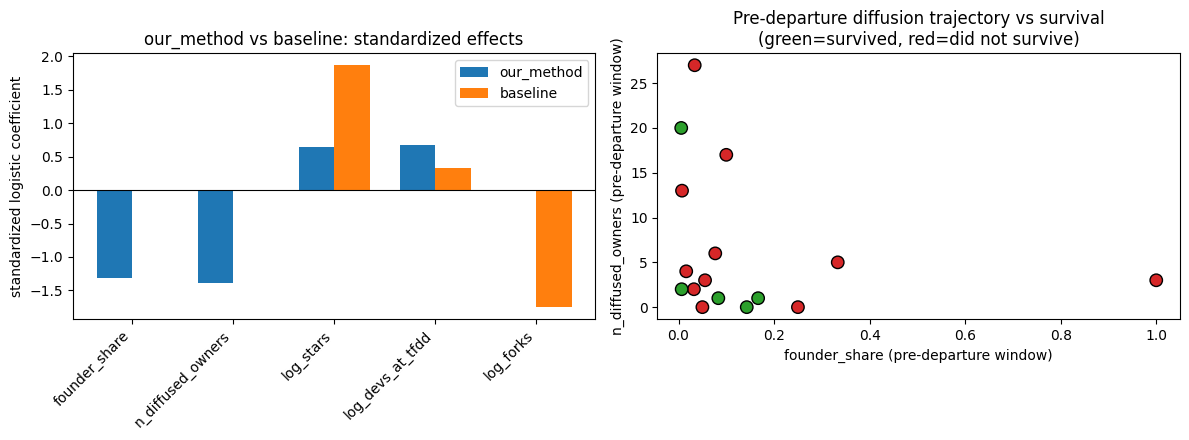

In [12]:
n_events = len(df)
n_survived = int(df["survived"].sum())
survival_rate = n_survived / n_events if n_events else float("nan")
print(f"Strict founder-only TFDD events analyzed: {n_events}")
print(f"Unconditioned 18-month post-TFDD survival rate: {survival_rate:.3f} ({n_survived}/{n_events})")
print(f"Avelino et al.'s reference survival rate:        0.41")
print(f"\nour_method pseudo-R^2:  {regression_our_method.get('pseudo_r2')}")
print(f"baseline   pseudo-R^2:  {regression_baseline_snapshot_only.get('pseudo_r2')}")
print(f"\nmatched-pairs: n_pairs={matched_pairs_result['n_pairs']}, risk_ratio={matched_pairs_result.get('risk_ratio_low_vs_high_diffusion')}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# left: standardized coefficients, our_method vs baseline
ax = axes[0]
our_std = regression_our_method.get("standardized_effect_sizes", {})
base_std = regression_baseline_snapshot_only.get("standardized_effect_sizes", {})
all_covs = list(dict.fromkeys(list(our_std.keys()) + list(base_std.keys())))
x = np.arange(len(all_covs))
width = 0.35
ax.bar(x - width/2, [our_std.get(c, 0) for c in all_covs], width, label="our_method")
ax.bar(x + width/2, [base_std.get(c, 0) for c in all_covs], width, label="baseline")
ax.set_xticks(x)
ax.set_xticklabels(all_covs, rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("standardized logistic coefficient")
ax.set_title("our_method vs baseline: standardized effects")
ax.legend()

# right: founder_share pre-departure vs survival outcome
ax = axes[1]
colors = df["survived"].map({True: "tab:green", False: "tab:red"})
ax.scatter(df["founder_share"], df["n_diffused_owners"], c=colors, s=80, edgecolor="black")
ax.set_xlabel("founder_share (pre-departure window)")
ax.set_ylabel("n_diffused_owners (pre-departure window)")
ax.set_title("Pre-departure diffusion trajectory vs survival\n(green=survived, red=did not survive)")

plt.tight_layout()
plt.show()